In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Dataset

In [3]:
california = datasets.fetch_california_housing()

In [4]:
california.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [5]:
california.data.shape

(20640, 8)

In [6]:
x = california.data

In [7]:
y = california.target

## Spilliting the dataset for test/train data

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size= 0.2, random_state= 11)

## Model

In [10]:
lr = LinearRegression()

## Fitting the model

In [11]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# weights

In [12]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [13]:
lr.coef_

array([ 4.33481147e-01,  9.13203774e-03, -1.00206297e-01,  6.11611814e-01,
       -5.80927065e-06, -3.41460825e-03, -4.26281098e-01, -4.41029824e-01])

## intercept

In [14]:
lr.intercept_

np.float64(-37.527853915226295)

## prediction

In [15]:
y_predict = lr.predict(x_test)

In [16]:
y_predict

array([1.24721229, 2.34670464, 2.03549825, ..., 1.49485254, 3.0196528 ,
       2.02082044], shape=(4128,))

In [17]:
y_predict_train = lr.predict(x_train)

In [18]:
y_predict_train

array([0.68985062, 2.91210697, 2.13868692, ..., 1.82562357, 2.32478817,
       1.96367541], shape=(16512,))

## Analysis

### On test data

In [19]:
r2_score(y_test,y_predict)

0.605787292569561

In [20]:
mean_squared_error(y_test,y_predict)

0.5304460892018628

In [21]:
mean_absolute_error(y_test,y_predict)

0.5385948841533721

### on train data

In [22]:
r2_score(y_train,y_predict_train)

0.6061334059992145

In [23]:
mean_squared_error(y_train, y_predict_train)

0.5229180518054782

In [24]:
mean_absolute_error(y_train, y_predict_train)

0.528427923269896

## Graph relation

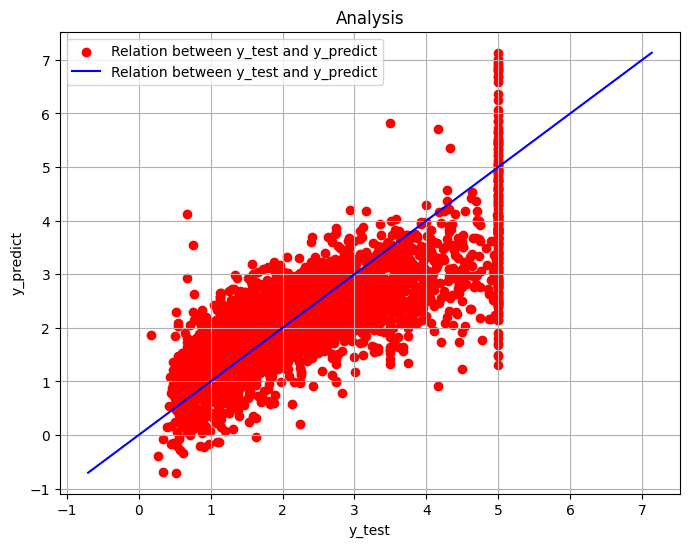

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_predict, color='red', label='Relation between y_test and y_predict')


mn = min(np.nanmin(y_test), np.nanmin(y_predict))
mx = max(np.nanmax(y_test), np.nanmax(y_predict))

plt.plot([mn, mx], [mn, mx], color='blue',label='Relation between y_test and y_predict')


plt.xlabel('y_test')
plt.ylabel('y_predict')
plt.title('Analysis')
plt.legend()
plt.grid(True)
plt.show()

## Homework

### Dataset 

In [26]:
california = datasets.fetch_california_housing()
x = california.data
y = california.target

### train/test splitting of dataset

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=21)

### Standardize the dataset

In [28]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

### Gradient descent code (Multiple linear regression)

In [29]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.lr = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = 0
        
    def fit(self, X, y):
        n, f = X.shape
        self.w = np.zeros(f)
        
        for i in range(self.epochs):
            y_pred = np.dot(X, self.w) + self.b
            error = y - y_pred
            
            dw = (-2/n) * np.dot(X.T, error)
            db = (-2/n) * np.sum(error)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
        print(f"After {self.epochs} epochs:")
        print("Weights:", self.w)
        print("Bias:", self.b)
        
    def predict(self, X):
        return np.dot(X, self.w) + self.b

### Fitting the model

In [30]:
gd_model = GDRegressor(learning_rate=0.01, epochs=1000)
gd_model.fit(x_train_scaled, y_train)

After 1000 epochs:
Weights: [ 0.82902491  0.14688851 -0.22568943  0.25300996  0.00843137 -0.04797325
 -0.68506019 -0.65841778]
Bias: 2.0653818950563605


### Prediction

In [31]:
y_predict_gd = gd_model.predict(x_test_scaled)

### Model prediction analysis

In [32]:
print(f"R2 Score: {r2_score(y_test, y_predict_gd)}")
print(f"MSE: {mean_squared_error(y_test, y_predict_gd)}")
print(f"MAE: {mean_absolute_error(y_test, y_predict_gd)}")

R2 Score: 0.5983655841048583
MSE: 0.5417446169308754
MAE: 0.5414923444812628


### Plot of actual and model prediction

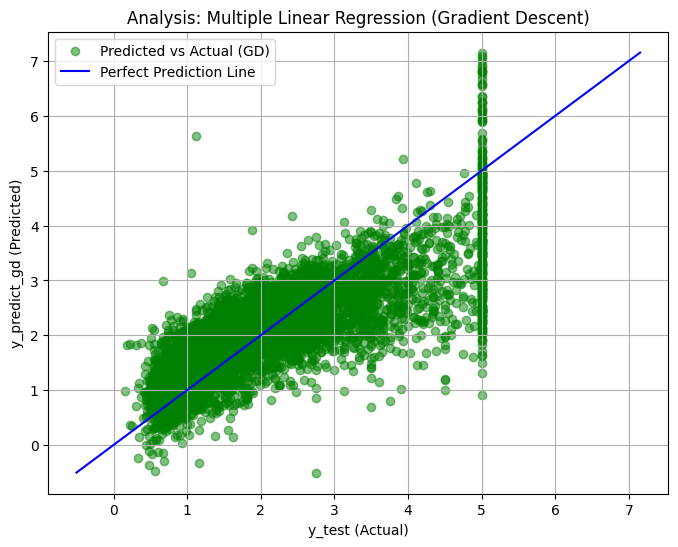

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predict_gd, color='green', label='Predicted vs Actual (GD)', alpha=0.5)
mn_gd = min(np.nanmin(y_test), np.nanmin(y_predict_gd))
mx_gd = max(np.nanmax(y_test), np.nanmax(y_predict_gd))

plt.plot([mn_gd, mx_gd], [mn_gd, mx_gd], color='blue', label='Perfect Prediction Line')

plt.xlabel('y_test (Actual)')
plt.ylabel('y_predict_gd (Predicted)')
plt.title('Analysis: Multiple Linear Regression (Gradient Descent)')
plt.legend()
plt.grid(True)
plt.show()